#Worksheet 04

###Building a Fully Connected Network (FCN) for Devnagari Digit Classification

####**Task 1: Data Preparation**

####**Loading the Data**


• Download the provided folder that contains the Devnagari digits dataset.


• Use the Python Imaging Library (PIL) to load and read the image files from the dataset.


• Convert the images into Numpy arrays and normalize them to a range of 0-1.


• use train folder for training and test for testing.


• Extract the corresponding labels for each image.


####**Hints:**

• Ensure that the images are resized to a consistent shape (e.g., 28x28).


• Convert labels to one-hot encoded format for multi-class classification.

In [16]:
import os
print(os.listdir('/content'))

['.config', 'devnagari.zip', 'DevanagariHandwrittenDigitDataset', '.ipynb_checkpoints', 'sample_data']


In [18]:
import zipfile

zip_path = "/content/devnagari.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')

In [19]:
print(os.listdir('/content'))

['.config', 'devnagari.zip', 'DevanagariHandwrittenDigitDataset', '.ipynb_checkpoints', 'sample_data']


In [20]:
import os
import numpy as np
from PIL import Image
from tensorflow.keras.utils import to_categorical

train_dir = "/content/DevanagariHandwrittenDigitDataset/Train/"
test_dir = "/content/DevanagariHandwrittenDigitDataset/Test/"

def load_images(folder):
    images = []
    labels = []

    class_names = sorted(os.listdir(folder))

    for i, class_name in enumerate(class_names):
        class_path = os.path.join(folder, class_name)

        for file in os.listdir(class_path):
            img_path = os.path.join(class_path, file)

            img = Image.open(img_path).convert("L")     # grayscale
            img = img.resize((28, 28))                  # resize
            img = np.array(img) / 255.0                 # normalize

            images.append(img)
            labels.append(i)

    return np.array(images), np.array(labels)

# Load data
x_train, y_train = load_images(train_dir)
x_test, y_test = load_images(test_dir)

# Reshape for FCN (IMPORTANT)
x_train = x_train.reshape(x_train.shape[0], 784)
x_test = x_test.reshape(x_test.shape[0], 784)

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape, y_test.shape)

Train: (17000, 784) (17000, 10)
Test : (3000, 784) (3000, 10)


###**Task 2: Build the FCN Model**
Model Architecture

• Create a Sequential model using Keras.

• Add 3 hidden layers with the following number of neurons:

– 1st hidden layer: 64 neurons

– 2nd hidden layer: 128 neurons

– 3rd hidden layer: 256 neurons

• Use sigmoid activation functions for all hidden layers.

• Add an output layer with 10 units with softmax (since Devnagari digits have 10 classes) and a
softmax activation function.

In [22]:
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Dense(64, activation='sigmoid', input_shape=(784,)),
    keras.layers.Dense(128, activation='sigmoid'),
    keras.layers.Dense(256, activation='sigmoid'),
    keras.layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

####**Task 3: Compile the Model**
Model Compilation

• Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy),
and evaluation metric (e.g., accuracy).

In [23]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

####**Task 4: Train the Model**
Model Training

• Use the model.fit() function to train the model. Set the batch size to 128 and the number of epochs to 20.

• Use validation split (validation split=0.2) to monitor the model’s performance on validation data.

• Optionally, use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model and avoiding overfitting.

In [25]:
from tensorflow import keras

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="best_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        verbose=1,
        restore_best_weights=True
    )
]

history = model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
100/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7625 - loss: 0.7374
Epoch 1: val_loss improved from None to 8.74392, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8058 - loss: 0.5840 - val_accuracy: 0.0000e+00 - val_loss: 8.7439
Epoch 2/20
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8816 - loss: 0.3434
Epoch 2: val_loss did not improve from 8.74392
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9028 - loss: 0.3062 - val_accuracy: 0.0000e+00 - val_loss: 9.2219
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9420 - loss: 0.2069
Epoch 3: val_loss did not improve from 8.74392
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9440 - loss: 0.1932 - val_accuracy: 0.0000e+00 - val_loss: 9.5943
Epoch 4/20
104/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9562 - loss: 0.1511
Epoch 4: val_loss did not improve from 8.74392
107/107 ━━━━━━━

In [26]:
import matplotlib.pyplot as plt

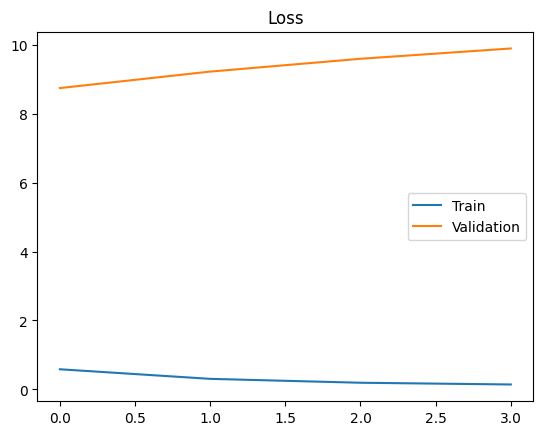

In [27]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train", "Validation"])
plt.show()

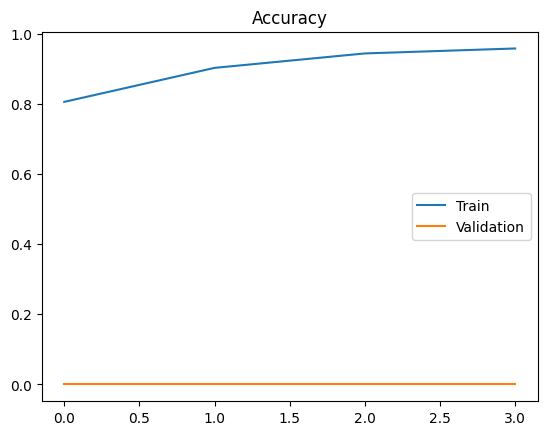

In [28]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

####**Task 5: Evaluate the Model**
####Model Evaluation

• After training, evaluate the model using model.evaluate() on the test set to check the test
accuracy and loss.

In [29]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6623 - loss: 2.0753
Test Accuracy: 0.6623333096504211
Test Loss: 2.0753114223480225


####**Task 6: Save and Load the Model**
Model Saving and Loading

• Save the trained model to an .h5 file using model.save().

• Load the saved model and re-evaluate its performance on the test set.

In [30]:
# Save
model.save("devnagari_model.keras")

# Load
loaded_model = keras.models.load_model("devnagari_model.keras")

# Evaluate
loss, acc = loaded_model.evaluate(x_test, y_test)
print("Loaded Model Accuracy:", acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6623 - loss: 2.0753
Loaded Model Accuracy: 0.6623333096504211


####**Task 7: Predictions**
####Making Predictions

• Use model.predict() to make predictions on test images.
• Convert the model’s predicted probabilities to digit labels using np.argmax().



In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Predict
predictions = model.predict(x_test)

# Convert probabilities → labels
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

# Show one example
print("Predicted:", predicted_labels[0])
print("Actual   :", true_labels[0])



94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted: 0
Actual   : 0


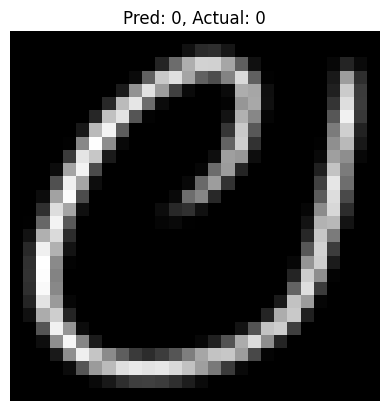

In [33]:
plt.imshow(x_test[0].reshape(28,28), cmap='gray')
plt.title(f"Pred: {predicted_labels[0]}, Actual: {true_labels[0]}")
plt.axis("off")
plt.show()